<a href="https://colab.research.google.com/github/ramyavalipe/GenAIColabNotebooks/blob/main/Unstructured_Data_Analytics_Campaign_Success_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 4
Group Members:


*   Krutika Kurup
*   Apurva Singh Chauhan
*   Manasi Hatekar
*   Ramya Valipe



# Task A

Scrape ~1000 fundraising campaigns in a particular category (e.g., Golden Retriever rescue society, an organization raising funds for wildfire victims, etc.). Fetch (i) image URLs, (ii) text description of a post, (iii) $ raised, (iv) how long the campaign has been running.

In [ ]:
# GoFundMe Dog Rescue Scraper

# ===== STEP 1: Install Packages =====
print("Installing packages...")
!pip install selenium pandas beautifulsoup4 python-dateutil -q
!apt-get update -qq
!apt-get install -y chromium-chromedriver -qq
print("Done!\n")

# ===== STEP 2: Import Libraries =====
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import pandas as pd
import time
from datetime import datetime
import re
import urllib.parse

# ===== STEP 3: Setup Driver =====
def setup_driver():
    opts = Options()
    opts.add_argument('--headless')
    opts.add_argument('--no-sandbox')
    opts.add_argument('--disable-dev-shm-usage')
    opts.add_argument('--disable-gpu')
    opts.add_argument('--window-size=1920,1080')
    opts.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
    return webdriver.Chrome(options=opts)

def parse_date_to_duration(date_str):
    """Convert date to duration text"""
    try:
        from dateutil import parser
        date = parser.parse(date_str)
        if date.tzinfo:
            date = date.replace(tzinfo=None)
        days = (datetime.now() - date).days

        if days < 0 or days > 3650:
            return None
        if days == 0:
            return "Created today"
        elif days == 1:
            return "Created 1 day ago"
        elif days < 7:
            return f"Created {days} days ago"
        elif days < 30:
            weeks = days // 7
            return f"Created {weeks} week{'s' if weeks > 1 else ''} ago"
        elif days < 365:
            months = days // 30
            return f"Created {months} month{'s' if months > 1 else ''} ago"
        else:
            years = days // 365
            return f"Created {years} year{'s' if years > 1 else ''} ago"
    except:
        return None

# ===== STEP 4: Extract Campaign Data =====
def extract_campaign(driver, url):
    """Extract all campaign data"""
    try:
        driver.get(url)
        time.sleep(3)

        data = {
            'campaign_url': url,
            'image_url': '',
            'description': '',
            'amount_raised': '',
            'campaign_duration': ''
        }

        soup = BeautifulSoup(driver.page_source, 'html.parser')

        # Image
        try:
            img = soup.find('meta', property='og:image')
            if img:
                data['image_url'] = img.get('content', '')
        except:
            pass

        # Description
        try:
            for tag in soup.find_all(['div', 'p']):
                if tag.get('class') and any('story' in str(c).lower() or 'description' in str(c).lower() for c in tag.get('class')):
                    text = tag.get_text(strip=True)
                    if len(text) > 100:
                        data['description'] = text[:500]
                        break
        except:
            pass

        # Amount - Enhanced with 5 methods
        amount = None

        # Method 1: og:description meta tag
        try:
            meta = soup.find('meta', property='og:description')
            if meta:
                content = meta.get('content', '')
                match = re.search(r'\$[\d,]+(?:\.\d{2})?\s+raised', content, re.I)
                if match:
                    amount = match.group(0).replace(' raised', '').strip()
        except:
            pass

        # Method 2: Search for elements with raised text
        if not amount:
            try:
                for elem in soup.find_all(['h2', 'h3', 'span', 'div', 'p']):
                    text = elem.get_text(strip=True)
                    if 'raised' in text.lower():
                        match = re.search(r'\$[\d,]+(?:\.\d{2})?', text)
                        if match:
                            amount = match.group(0)
                            break
            except:
                pass

        # Method 3: Look in progress sections
        if not amount:
            try:
                for elem in soup.find_all(['div', 'section']):
                    if elem.get('class'):
                        class_str = ' '.join(elem.get('class'))
                        if any(kw in class_str.lower() for kw in ['progress', 'amount', 'raised']):
                            text = elem.get_text(strip=True)
                            match = re.search(r'\$[\d,]+(?:\.\d{2})?', text)
                            if match and 'raised' in text.lower():
                                amount = match.group(0)
                                break
            except:
                pass

        # Method 4: Selenium search
        if not amount:
            try:
                xpath_query = "//*[contains(text(), '$')]"
                money_elems = driver.find_elements(By.XPATH, xpath_query)
                for elem in money_elems:
                    try:
                        elem_text = elem.text
                        if 'raised' in elem_text.lower():
                            match = re.search(r'\$[\d,]+(?:\.\d{2})?', elem_text)
                            if match:
                                amount = match.group(0)
                                break
                    except:
                        continue
            except:
                pass

        # Method 5: Page source JSON
        if not amount:
            try:
                page_src = driver.page_source
                patterns = [
                    r'"current_amount":\s*(\d+)',
                    r'"amount_raised":\s*(\d+)',
                    r'"raised":\s*(\d+)'
                ]
                for pattern in patterns:
                    match = re.search(pattern, page_src)
                    if match:
                        cents = int(match.group(1))
                        dollars = cents / 100 if cents > 1000 else cents
                        amount = f"${int(dollars):,}"
                        break
            except:
                pass

        data['amount_raised'] = amount if amount else '$0'

        # Duration - 3 methods
        duration = None

        # Method 1: Find span with Created
        try:
            for span in soup.find_all('span'):
                text = span.get_text(strip=True)

                if re.match(r'^Created\s+\d+\s+d\s+ago$', text, re.I):
                    num = re.search(r'\d+', text).group()
                    duration = f"Created {num} day{'s' if int(num) > 1 else ''} ago"
                    break

                if re.match(r'^Created\s+\d+\s+mo\s+ago$', text, re.I):
                    num = re.search(r'\d+', text).group()
                    duration = f"Created {num} month{'s' if int(num) > 1 else ''} ago"
                    break

                if re.match(r'^Created\s+\d+\s+yr\s+ago$', text, re.I):
                    num = re.search(r'\d+', text).group()
                    duration = f"Created {num} year{'s' if int(num) > 1 else ''} ago"
                    break

                match = re.match(r'^Created\s+([A-Z][a-z]+)\s+(\d{1,2})(?:st|nd|rd|th)?,?\s+(\d{4})$', text)
                if match:
                    date_str = f"{match.group(1)} {match.group(2)}, {match.group(3)}"
                    duration = parse_date_to_duration(date_str)
                    if duration:
                        break
        except:
            pass

        # Method 2: Search page text
        if not duration:
            try:
                text = soup.get_text()

                patterns = [
                    (r'Created\s+(\d+)\s+d\s+ago', 'day'),
                    (r'Created\s+(\d+)\s+mo\s+ago', 'month'),
                    (r'Created\s+(\d+)\s+yr\s+ago', 'year')
                ]

                for pattern, unit in patterns:
                    match = re.search(pattern, text, re.I)
                    if match:
                        num = int(match.group(1))
                        plural = 's' if num > 1 else ''
                        duration = f"Created {num} {unit}{plural} ago"
                        break

                if not duration:
                    match = re.search(r'Created\s+([A-Z][a-z]+)\s+(\d{1,2})(?:st|nd|rd|th)?,?\s+(\d{4})', text)
                    if match:
                        date_str = f"{match.group(1)} {match.group(2)}, {match.group(3)}"
                        duration = parse_date_to_duration(date_str)
            except:
                pass

        # Method 3: Selenium
        if not duration:
            try:
                xpath_query = "//span[contains(text(), 'Created') or contains(text(), 'created')]"
                elems = driver.find_elements(By.XPATH, xpath_query)
                for elem in elems:
                    txt = elem.text.strip()

                    if re.match(r'^Created\s+\d+\s+d\s+ago$', txt, re.I):
                        num = re.search(r'\d+', txt).group()
                        duration = f"Created {num} day{'s' if int(num) > 1 else ''} ago"
                        break

                    if re.match(r'^Created\s+\d+\s+mo\s+ago$', txt, re.I):
                        num = re.search(r'\d+', txt).group()
                        duration = f"Created {num} month{'s' if int(num) > 1 else ''} ago"
                        break

                    if re.match(r'^Created\s+\d+\s+yr\s+ago$', txt, re.I):
                        num = re.search(r'\d+', txt).group()
                        duration = f"Created {num} year{'s' if int(num) > 1 else ''} ago"
                        break
            except:
                pass

        data['campaign_duration'] = duration if duration else 'Duration not found'
        return data

    except:
        return None

# ===== STEP 5: Search Campaigns =====
def search_campaigns(driver, query, max_results=15):
    """Search and get campaign URLs - INCREASED results per search"""
    try:
        url = f"https://www.gofundme.com/s?q={urllib.parse.quote(query + ' dog rescue')}"
        driver.get(url)
        time.sleep(3)

        links = set()

        # Scroll to load more results
        try:
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(2)
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(2)
        except:
            pass

        for elem in driver.find_elements(By.XPATH, "//a[contains(@href, '/f/')]"):
            href = elem.get_attribute('href')
            if href and '/f/' in href:
                links.add(href.split('?')[0])
                if len(links) >= max_results:
                    break
        return list(links)
    except:
        return []

# ===== STEP 6: Main Scraper =====
def scrape_campaigns(total=1000):
    """Main scraping function"""

    breeds = [
        # Popular breeds
        "Labrador", "Golden Retriever", "German Shepherd", "Bulldog", "Beagle",
        "Poodle", "Husky", "Great Dane", "Rottweiler", "Boxer", "Dachshund",
        "Pomeranian", "Chihuahua", "Border Collie", "Australian Shepherd",
        "Pug", "Cocker Spaniel", "Doberman", "Shih Tzu", "Maltese",
        "Yorkshire Terrier", "Mastiff", "Basset Hound", "Dalmatian",
        "Bichon Frise", "Collie", "Akita", "Newfoundland", "Bloodhound",
        "Bernese Mountain Dog", "Weimaraner", "Springer Spaniel", "Pointer",
        "Samoyed", "Saint Bernard", "Alaskan Malamute", "Chow Chow",
        "Basenji", "Whippet", "Greyhound", "Papillon", "Jack Russell",
        "Miniature Schnauzer", "Shiba Inu", "Lhasa Apso", "Pekingese",

        # Additional breeds
        "Pitbull", "American Bully", "Cane Corso", "Bull Terrier", "Boston Terrier",
        "French Bulldog", "English Bulldog", "American Bulldog", "Staffordshire Terrier",
        "Cairn Terrier", "West Highland Terrier", "Scottish Terrier", "Irish Setter",
        "English Setter", "Gordon Setter", "Vizsla", "Rhodesian Ridgeback",
        "Afghan Hound", "Saluki", "Irish Wolfhound", "Scottish Deerhound",
        "Borzoi", "Great Pyrenees", "Anatolian Shepherd", "Komondor",
        "Kuvasz", "Maremma", "Leonberger", "Tibetan Mastiff", "Caucasian Shepherd",
        "Belgian Malinois", "Belgian Sheepdog", "Belgian Tervuren", "Dutch Shepherd",
        "Australian Cattle Dog", "Blue Heeler", "Red Heeler", "Cattle Dog",
        "Catahoula", "Plott Hound", "Redbone Coonhound", "Bluetick Coonhound",
        "Treeing Walker", "Black and Tan Coonhound", "English Coonhound",
        "Foxhound", "Beagle Mix", "Hound Mix", "Terrier Mix", "Shepherd Mix",
        "Lab Mix", "Retriever Mix", "Spaniel Mix", "Poodle Mix", "Doodle",
        "Goldendoodle", "Labradoodle", "Aussiedoodle", "Bernedoodle", "Cockapoo",
        "Schnoodle", "Maltipoo", "Yorkipoo", "Cavapoo", "Sheepadoodle",

        # Medical/injury terms
        "injured dog", "sick dog", "emergency dog", "accident dog", "hit by car dog",
        "surgery dog", "medical dog", "treatment dog", "vet bills dog", "paralyzed dog",
        "broken leg dog", "cancer dog", "tumor dog", "blind dog", "deaf dog",
        "amputee dog", "disabled dog", "special needs dog", "hospice dog",

        # Rescue situations
        "abandoned dog", "abused dog", "neglected dog", "starving dog", "emaciated dog",
        "hoarding dog", "mill dog", "puppy mill", "fighting dog", "bait dog",
        "rescued dog", "stray dog", "street dog", "homeless dog", "shelter dog",
        "foster dog", "rescue dog", "saved dog", "urgent dog", "emergency rescue dog",

        # Life stages
        "puppy", "puppies", "senior dog", "old dog", "elderly dog", "aged dog",
        "baby dog", "young dog", "pregnant dog", "nursing dog", "litter of puppies",

        # Types and mixes
        "mixed breed", "mutt", "crossbreed", "designer dog", "hybrid dog",
        "small dog", "large dog", "giant dog", "toy dog", "miniature dog",
        "service dog", "therapy dog", "emotional support dog", "working dog",
        "guard dog", "police dog", "military dog", "farm dog", "hunting dog",

        # Additional rescue terms
        "dog in need", "help dog", "save dog", "dog medical fund", "dog surgery fund",
        "dog emergency fund", "dog vet bills", "dog treatment", "dog care",
        "animal rescue", "pet rescue", "canine rescue", "dog sanctuary",
        "dog recovery", "dog rehabilitation", "dog adoption"
    ]

    driver = setup_driver()
    all_links = []
    results = []

    try:
        print("="*60)
        print("GOFUNDME DOG RESCUE SCRAPER")
        print("="*60)
        print(f"Target: {total} campaigns\n")

        # Phase 1: Collect links
        print("Phase 1: Collecting campaign URLs...")
        print("-"*60)

        needed = (total // 12) + 5
        for i, breed in enumerate(breeds[:needed], 1):
            print(f"[{i}/{needed}] {breed}...", end=" ")
            links = search_campaigns(driver, breed)
            all_links.extend(links)
            print(f"{len(links)} found (Total: {len(all_links)})")

            if len(all_links) >= total * 1.2:
                break
            time.sleep(1.5)

        all_links = list(set(all_links))[:total]
        print(f"\nCollected {len(all_links)} unique campaigns\n")

        # Phase 2: Extract data
        print("Phase 2: Extracting campaign data...")
        print("="*60)

        for i, url in enumerate(all_links, 1):
            data = extract_campaign(driver, url)

            if data:
                data['campaign_number'] = i
                results.append(data)

                status = "SUCCESS" if data['campaign_duration'] != 'Duration not found' else "MISSING"
                print(f"[{i}/{len(all_links)}] {status} | {data['amount_raised']} | {data['campaign_duration']}")
            else:
                print(f"[{i}/{len(all_links)}] FAILED")

            # Progress report
            if i % 50 == 0:
                success = sum(1 for r in results if r['campaign_duration'] != 'Duration not found')
                rate = (success / len(results) * 100) if results else 0
                print(f"\n--- Progress: {i}/{len(all_links)} | Duration: {rate:.1f}% ({success}/{len(results)}) ---\n")

            time.sleep(2)

        # Save results
        if not results:
            print("\nNo data collected")
            return None, None

        df = pd.DataFrame(results)
        df = df[['campaign_number', 'image_url', 'description', 'amount_raised', 'campaign_duration', 'campaign_url']]

        filename = f'gofundme_dogs_{datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
        df.to_csv(filename, index=False, encoding='utf-8')

        # Summary
        print("\n" + "="*60)
        print("SUMMARY")
        print("="*60)
        print(f"Total campaigns: {len(results)}")
        print(f"With images: {df['image_url'].astype(bool).sum()} ({df['image_url'].astype(bool).sum()/len(df)*100:.1f}%)")
        print(f"With descriptions: {df['description'].astype(bool).sum()} ({df['description'].astype(bool).sum()/len(df)*100:.1f}%)")
        print(f"With amounts: {df['amount_raised'].astype(bool).sum()} ({df['amount_raised'].astype(bool).sum()/len(df)*100:.1f}%)")

        dur_count = (df['campaign_duration'] != 'Duration not found').sum()
        print(f"With duration: {dur_count} ({dur_count/len(df)*100:.1f}%)")
        print(f"\nSaved: {filename}\n")

        return df, filename

    except Exception as e:
        print(f"\nError: {e}")
        import traceback
        traceback.print_exc()
        return None, None
    finally:
        driver.quit()

# ===== RUN =====
if __name__ == "__main__":
    print("="*60)
    print("GOFUNDME DOG RESCUE SCRAPER")
    print("="*60)
    print("\nThis will scrape 1000 dog rescue campaigns")
    print("Estimated time: 45-60 minutes")
    print("="*60 + "\n")

    confirm = input("Start scraping? (yes/no): ").strip().lower()

    if confirm in ['yes', 'y']:
        df, filename = scrape_campaigns(1000)

        if df is not None:
            print("\nCOMPLETE!\n")
            from google.colab import files
            files.download(filename)
            print("Downloaded!")
        else:
            print("\nFailed")
    else:
        print("Cancelled")

Installing packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.0/512.0 kB 14.0 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package apparmor.
(Reading database ... 125080 files and directories currently installed.)
Preparing to unpack .../apparmor_3.0.4-2ubuntu2.4_amd64.deb ...
Unpacking apparmor (3.0.4-2ubuntu2.4) ...
Selecting previously unselected package squashfs-tools.
Preparing to unpack .../squashfs-tools_1%3a4.5-3build1_amd64.deb ...
Unpacking squashfs-tools (1:4.5-3build1) ...
Preparing to unpack .../libudev1_249.11-0ubuntu3.17_amd64.deb ...
Unpacking libudev1:amd64 (249.11-0ubuntu3.17) over (249.11-0ubuntu3.12) ...
Setting up libudev1:amd64 (249.11-0ubuntu3.17) ...
Selecting 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!


# Task B

Using the image URLs, obtain image labels (text) from Google Vision (cloud service) or other services such as Azure. You can also use an LLM through its API. You will need an account, though.

**Approach:**

Our code automates getting image labels from Google Cloud Vision API for all campaign images in our dataset.
We first upload our CSV file (containing image URLs) and Google Cloud authentication key. The code then reads all image URLs and sends them to Google's Vision API in batches of 16 images at a time to respect API limits.
For each image, Vision API analyzes the content and returns descriptive labels - words like "dog", "outdoor", "shelter" that describe what's visible. These labels are added back to our CSV in two formats: a list and comma-separated text.
We use batching (16 images per request) because processing hundreds of images individually would be slow and could hit rate limits. A 1-second pause between batches ensures we stay within Google's usage guidelines. Once complete, we have a new CSV with image labels ready for analysis.

In [ ]:
!pip install google-cloud-vision

In [ ]:
from google.colab import files
import os
import pandas as pd

print("Please upload your CSV file and your Google Cloud JSON key file.")
uploaded = files.upload()

# Find the file types and set variables
json_key_file = None
csv_file = None

for fn in uploaded.keys():
  if fn.endswith('.json'):
    json_key_file = fn
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = json_key_file
    print(f"Found JSON key: {fn}")
  elif fn.endswith('.csv'):
    csv_file = fn
    print(f"Found CSV file: {fn}")

if not json_key_file:
  print("Error: No JSON key file was uploaded.")
if not csv_file:
  print("Error: No CSV file was uploaded.")

Please upload your CSV file and your Google Cloud JSON key file.


Saving gofundme_scrapingdata.csv to gofundme_scrapingdata.csv
Saving vision_key.json to vision_key.json
Found CSV file: gofundme_scrapingdata.csv
Found JSON key: vision_key.json


In [ ]:
# --- Imports ---
import math
import time
import pandas as pd
from google.cloud import vision

# --- 1. Define Your CSV Column Name ---
# ⚠️ IMPORTANT: Change this if your image URL column has a different name.
URL_COLUMN_NAME = 'image_url'

# --- 2. Define the API Batch Size Limit ---
BATCH_SIZE = 16

if 'csv_file' in locals() and csv_file:
    try:
        # --- 3. Read URLs from CSV ---
        df = pd.read_csv(csv_file)

        if URL_COLUMN_NAME not in df.columns:
            print(f"Error: Column '{URL_COLUMN_NAME}' not found in the CSV.")
            print(f"Available columns are: {df.columns.tolist()}")
        else:
            image_urls = df[URL_COLUMN_NAME].dropna().tolist()
            if not image_urls:
                print("No image URLs found in that column.")
            else:
                print(f"Found {len(image_urls)} URLs in the CSV.")

                # --- 4. Run Vision API in Chunks ---
                client = vision.ImageAnnotatorClient()
                total_batches = math.ceil(len(image_urls) / BATCH_SIZE)
                print(f"Splitting into {total_batches} batches of {BATCH_SIZE} images each...")

                # Initialize dictionary to store labels
                label_dict = {}

                # --- 5. Process Each Batch ---
                for i in range(0, len(image_urls), BATCH_SIZE):
                    current_batch_urls = image_urls[i:i + BATCH_SIZE]
                    current_batch_num = (i // BATCH_SIZE) + 1

                    print(f"\nProcessing Batch {current_batch_num}/{total_batches}...")

                    # Build requests
                    requests = []
                    for url in current_batch_urls:
                        image = vision.Image()
                        image.source.image_uri = url
                        feature = vision.Feature(type_=vision.Feature.Type.LABEL_DETECTION)
                        request = vision.AnnotateImageRequest(image=image, features=[feature])
                        requests.append(request)

                    # Call API
                    response = client.batch_annotate_images(requests=requests)

                    # Process each image in the batch
                    for j, image_response in enumerate(response.responses):
                        full_index = i + j
                        image_url = image_urls[full_index]

                        if image_response.error.message:
                            label_dict[image_url] = [f"ERROR: {image_response.error.message}"]
                            continue

                        labels = image_response.label_annotations
                        if not labels:
                            label_dict[image_url] = []
                        else:
                            label_dict[image_url] = [label.description for label in labels]

                    # Short delay to respect rate limits
                    time.sleep(1)

                print("\n✅ All batches processed successfully!")

                # --- 6. Add Labels to DataFrame ---
                df['image_labels'] = df[URL_COLUMN_NAME].map(label_dict)
                df['image_labels_str'] = df['image_labels'].apply(
                    lambda x: ', '.join(x) if isinstance(x, list) else ''
                )

                # --- 7. Save to CSV ---
                output_path = "labeled_images.csv"
                df.to_csv(output_path, index=False)
                print(f"\n✅ Labeled data saved to {output_path}")

    except Exception as e:
        print(f"An error occurred: {e}")
else:
    print("Please run the cell above to upload your files first.")


Found 990 URLs in the CSV.
Splitting into 62 batches of 16 images each...

Processing Batch 1/62...

Processing Batch 2/62...

Processing Batch 3/62...

Processing Batch 4/62...

Processing Batch 5/62...

Processing Batch 6/62...

Processing Batch 7/62...

Processing Batch 8/62...

Processing Batch 9/62...

Processing Batch 10/62...

Processing Batch 11/62...

Processing Batch 12/62...

Processing Batch 13/62...

Processing Batch 14/62...

Processing Batch 15/62...

Processing Batch 16/62...

Processing Batch 17/62...

Processing Batch 18/62...

Processing Batch 19/62...

Processing Batch 20/62...

Processing Batch 21/62...

Processing Batch 22/62...

Processing Batch 23/62...

Processing Batch 24/62...

Processing Batch 25/62...

Processing Batch 26/62...

Processing Batch 27/62...

Processing Batch 28/62...

Processing Batch 29/62...

Processing Batch 30/62...

Processing Batch 31/62...

Processing Batch 32/62...

Processing Batch 33/62...

Processing Batch 34/62...

Processing Batch

In [ ]:
# --- Download and Inspect the Labeled CSV ---
import pandas as pd
from IPython.display import display
import os

output_path = "labeled_images.csv"

if os.path.exists(output_path):
    # Load the labeled data
    df_labeled = pd.read_csv(output_path)

    # Show a preview of the new columns
    print(f"✅ Successfully loaded {output_path}")
    print(f"Columns: {df_labeled.columns.tolist()}")
    print(f"Total rows: {len(df_labeled)}\n")

    # Display first few rows to verify labels
    display(df_labeled.head(5))

    # Optional: if you're in Google Colab and want to download locally
    try:
        from google.colab import files
        files.download(output_path)
    except ImportError:
        print("💡 Not in Colab environment — skipping auto-download.")
        print(f"You can manually download the file from your working directory: {os.getcwd()}")
else:
    print("❌ labeled_images.csv not found. Make sure you ran the labeling script first.")


✅ Successfully loaded labeled_images.csv
Columns: ['campaign_number', 'image_url', 'description', 'amount_raised', 'campaign_duration', 'campaign_url', 'image_labels', 'image_labels_str']
Total rows: 1000



,campaign_number,image_url,description,amount_raised,campaign_duration,campaign_url,image_labels,image_labels_str
0,1,https://d2g8igdw686xgo.cloudfront.net/69002149...,StorySylvie was found as a stray and taken to ...,"$2,065.00",Created 3 years ago,https://www.gofundme.com/f/help-needed-with-sy...,"['Dog', 'Carnivores', 'Vertebrate', 'Snout', '...","Dog, Carnivores, Vertebrate, Snout, Fur, Worki..."
1,2,https://d2g8igdw686xgo.cloudfront.net/80884391...,StoryLibby is a 6 year old Lemon and White Eng...,$750.00,Created 1 year ago,https://www.gofundme.com/f/g3qfur-libby-needs-...,"['Dog', 'Carnivores', 'Vertebrate', 'Working a...","Dog, Carnivores, Vertebrate, Working animal, S..."
2,3,https://d2g8igdw686xgo.cloudfront.net/68881375...,"StoryOn Thursday morning, Tammy, a volunteer w...","$9,668.00",Created 3 years ago,https://www.gofundme.com/f/louie-the-basset-hi...,"['Dog', 'Carnivores', 'Vertebrate', 'Snout', '...","Dog, Carnivores, Vertebrate, Snout, Working an..."
3,4,https://d2g8igdw686xgo.cloudfront.net/89522507...,StoryCanelo was dumped by his previous family ...,$0.00,Created 7 months ago,https://www.gofundme.com/f/help-out-rescue-dog...,"['Dog', 'Carnivores', 'Vertebrate', 'Snout', '...","Dog, Carnivores, Vertebrate, Snout, Close-up, ..."
4,5,https://d2g8igdw686xgo.cloudfront.net/54443548...,"StoryOur Mothra, the spiciest meatball, the st...","$4,334.00",Created 4 years ago,https://www.gofundme.com/f/help-mothra-beat-ca...,"['Dog', 'Vertebrate', 'Carnivores', 'Snout', '...","Dog, Vertebrate, Carnivores, Snout, Close-up, ..."


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task C

Create a column called binary (lowercase only) where value =1 (stands for high $$) or 0 (stands for low $) based on the median value.  

In [ ]:
import pandas as pd

# Step 1: Load the CSV file
df = pd.read_csv("labeled_images.csv")

# Step 2: Clean the 'amount_raised' column — remove '$' and commas, convert to float
df['amount_raised'] = df['amount_raised'].replace('[\$,]', '', regex=True).astype(float)

# Step 3: Compute mean of 'amount_raised'
mean_amount = df['amount_raised'].mean()
print(f"Mean amount raised: ${mean_amount:.2f}")

# Step 4: Compute median to classify high ($$) and low ($)
median_amount = df['amount_raised'].median()

# Step 5: Create a new binary column
df['binary'] = (df['amount_raised'] > median_amount).astype(int)

# Step 6: Save to a new CSV
df.to_csv("labeled_images_with_binary.csv", index=False)

print("New CSV file 'labeled_images_with_binary.csv' created successfully!")


Mean amount raised: $3218.91
New CSV file 'labeled_images_with_binary.csv' created successfully!


<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2554692789.py:7: SyntaxWarning: invalid escape sequence '\$'
  df['amount_raised'] = df['amount_raised'].replace('[\$,]', '', regex=True).astype(float)


# Task D

Run a logistic regression with binary as the dependent variable, and the image_labels as independent variables. You can use a BoW model for text. Figure out how you can use the duration of the campaign in the model. What is the accuracy (show the confusion matrix) of this prediction model? The idea is to be able to predict the engagement level for an image.
Accuracy = 1 - # prediction errors / total # cases
What accuracy do you get by using the description words as the independent variables instead of image_labels? Finally, what accuracy do you get by combining (concatenating) the image_labels and word descriptions and using them together as independent variables? What can you conclude from your analysis?


**Approach:**

This code builds three logistic regression models to predict whether a fundraising campaign will raise above or below the median amount. We test three approaches: using only image labels, only text descriptions, or both combined. The text is converted to numerical features using Bag of Words with bigrams to capture word patterns.
Duration Integration: Campaign duration is crucial since older campaigns have more time to accumulate funds. We extract the duration in days from text like "Created 2 years ago", apply a log transformation to normalize the wide range of values, then scale it to match the text features. This scaled duration is added as an additional numeric feature in the model, allowing it to learn from both content (visual/textual) and time factors. Comparing the three models reveals which content type best predicts fundraising success.

✓ Data prepared: 1000 campaigns
✓ Binary class distribution: {1: 500, 0: 500}

MODEL 1: Image Labels + Duration
Best Parameters: C=0.001
Test Accuracy: 0.7000

Confusion Matrix:
                Predicted Low $  Predicted High $
Actual Low $            90               60
Actual High $           30              120

MODEL 2: Description + Duration
Best Parameters: C=0.01
Test Accuracy: 0.6533

Confusion Matrix:
                Predicted Low $  Predicted High $
Actual Low $            98               52
Actual High $           52               98

MODEL 3: Combined + Duration
Best Parameters: C=0.01
Test Accuracy: 0.6633

Confusion Matrix:
                Predicted Low $  Predicted High $
Actual Low $           100               50
Actual High $           51               99

SUMMARY: MODEL COMPARISON

            Model  Accuracy
Image Labels Only  0.700000
         Combined  0.663333
 Description Only  0.653333

🏆 Best Model: Image Labels Only
🏆 Best Accuracy: 0.7000


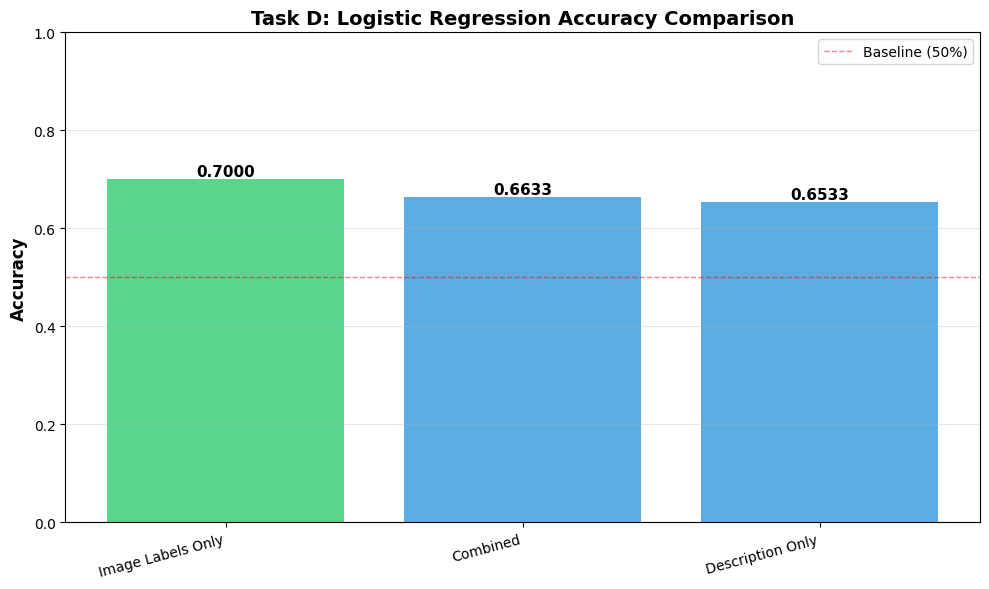

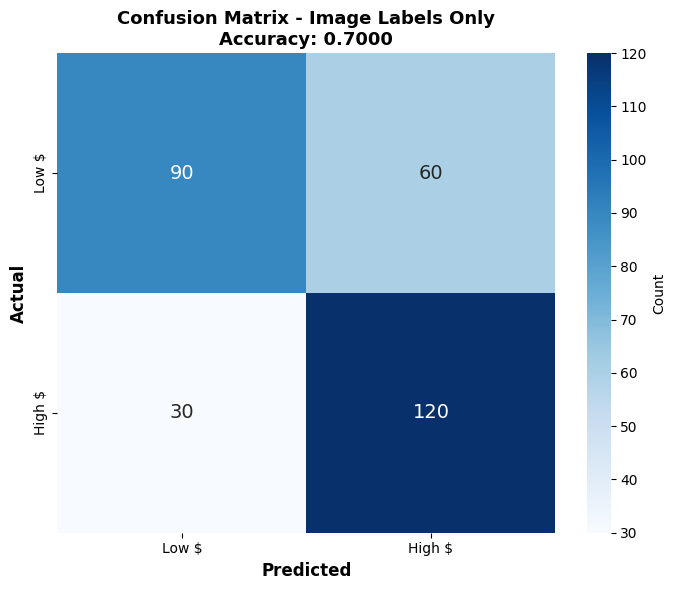


KEY FINDINGS

📊 Accuracy Results:
   • Image Labels:  0.7000
   • Description:   0.6533
   • Combined:      0.6633

💡 Analysis:
   ✓ Image labels are more predictive than descriptions
   ✓ Visual content is the stronger indicator of fundraising success

✓ Results saved to: task_d_results.csv

TASK D COMPLETED!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Data Preparation
# ============================================================================

# Handle missing values
df['image_labels_str'] = df['image_labels_str'].fillna('').astype(str)
df['description'] = df['description'].fillna('').astype(str)

# Extract duration in days
def extract_duration_days(duration_str):
    duration_str = str(duration_str).lower()
    if 'year' in duration_str:
        return int(''.join(filter(str.isdigit, duration_str))) * 365
    elif 'month' in duration_str:
        return int(''.join(filter(str.isdigit, duration_str))) * 30
    elif 'week' in duration_str:
        return int(''.join(filter(str.isdigit, duration_str))) * 7
    elif 'day' in duration_str:
        return int(''.join(filter(str.isdigit, duration_str)))
    else:
        return 0

df['duration_days'] = df['campaign_duration'].apply(extract_duration_days)
df['duration_log'] = np.log1p(df['duration_days'])

# Text preprocessing
def preprocess_text(text_series):
    text_series = text_series.str.lower().str.strip()
    text_series = text_series.str.replace(r'[^a-z\s]', ' ', regex=True)
    text_series = text_series.str.replace(r'\s+', ' ', regex=True)
    return text_series

df['image_labels_clean'] = preprocess_text(df['image_labels_str'])
df['description_clean'] = preprocess_text(df['description'])

print(f"✓ Data prepared: {len(df)} campaigns")
print(f"✓ Binary class distribution: {df['binary'].value_counts().to_dict()}")

# ============================================================================
# Model Training Function
# ============================================================================

def train_model(X, y, model_name):
    """Train and evaluate logistic regression model"""

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # Grid search for best parameters
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
        'max_iter': [1000]
    }

    grid_search = GridSearchCV(
        LogisticRegression(class_weight='balanced', random_state=42),
        param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    # Predictions
    y_pred_test = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    cm = confusion_matrix(y_test, y_pred_test)

    # Print results
    print(f"\n{'='*70}")
    print(f"{model_name}")
    print('='*70)
    print(f"Best Parameters: C={grid_search.best_params_['C']}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"                Predicted Low $  Predicted High $")
    print(f"Actual Low $         {cm[0,0]:5d}            {cm[0,1]:5d}")
    print(f"Actual High $        {cm[1,0]:5d}            {cm[1,1]:5d}")

    return {
        'model': best_model,
        'accuracy': test_accuracy,
        'confusion_matrix': cm,
        'y_test': y_test,
        'y_pred': y_pred_test
    }

# ============================================================================
# MODEL 1: Image Labels Only
# ============================================================================

vectorizer_img = CountVectorizer(
    max_features=500, min_df=2, max_df=0.8, ngram_range=(1, 2)
)
X_text_img = vectorizer_img.fit_transform(df['image_labels_clean'])

scaler_img = StandardScaler()
X_duration_img = scaler_img.fit_transform(df[['duration_log']])

X_img = hstack([X_text_img, X_duration_img])
result_img = train_model(X_img, df['binary'], "MODEL 1: Image Labels + Duration")

# ============================================================================
# MODEL 2: Description Only
# ============================================================================

vectorizer_desc = CountVectorizer(
    max_features=500, min_df=2, max_df=0.8, ngram_range=(1, 2)
)
X_text_desc = vectorizer_desc.fit_transform(df['description_clean'])

scaler_desc = StandardScaler()
X_duration_desc = scaler_desc.fit_transform(df[['duration_log']])

X_desc = hstack([X_text_desc, X_duration_desc])
result_desc = train_model(X_desc, df['binary'], "MODEL 2: Description + Duration")

# ============================================================================
# MODEL 3: Combined (Image Labels + Description)
# ============================================================================

df['combined_text'] = df['image_labels_clean'] + ' ' + df['description_clean']

vectorizer_comb = CountVectorizer(
    max_features=800, min_df=2, max_df=0.8, ngram_range=(1, 2)
)
X_text_comb = vectorizer_comb.fit_transform(df['combined_text'])

scaler_comb = StandardScaler()
X_duration_comb = scaler_comb.fit_transform(df[['duration_log']])

X_comb = hstack([X_text_comb, X_duration_comb])
result_comb = train_model(X_comb, df['binary'], "MODEL 3: Combined + Duration")

# ============================================================================
# Summary Comparison
# ============================================================================

print("\n" + "="*70)
print("SUMMARY: MODEL COMPARISON")
print("="*70)

summary_df = pd.DataFrame([
    {'Model': 'Image Labels Only', 'Accuracy': result_img['accuracy']},
    {'Model': 'Description Only', 'Accuracy': result_desc['accuracy']},
    {'Model': 'Combined', 'Accuracy': result_comb['accuracy']}
])
summary_df = summary_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + summary_df.to_string(index=False))

best_model = summary_df.iloc[0]['Model']
best_acc = summary_df.iloc[0]['Accuracy']

print(f"\n🏆 Best Model: {best_model}")
print(f"🏆 Best Accuracy: {best_acc:.4f}")

# Determine best result for visualization
if best_model == 'Image Labels Only':
    best_result = result_img
elif best_model == 'Description Only':
    best_result = result_desc
else:
    best_result = result_comb

# ============================================================================
# Visualizations
# ============================================================================

# Plot 1: Accuracy Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(summary_df))]
bars = ax.bar(summary_df['Model'], summary_df['Accuracy'], color=colors, alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Task D: Logistic Regression Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Baseline (50%)')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Plot 2: Confusion Matrix for Best Model
fig, ax = plt.subplots(figsize=(7, 6))
cm = best_result['confusion_matrix']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low $', 'High $'],
            yticklabels=['Low $', 'High $'],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})

ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix - {best_model}\nAccuracy: {best_acc:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# Key Findings
# ============================================================================

print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

img_acc = result_img['accuracy']
desc_acc = result_desc['accuracy']
comb_acc = result_comb['accuracy']

print(f"\n📊 Accuracy Results:")
print(f"   • Image Labels:  {img_acc:.4f}")
print(f"   • Description:   {desc_acc:.4f}")
print(f"   • Combined:      {comb_acc:.4f}")

print(f"\n💡 Analysis:")
if comb_acc > max(img_acc, desc_acc):
    print("   ✓ Combining image labels and descriptions improves prediction")
    print("   ✓ Both visual and textual features contribute to fundraising success")
elif img_acc > desc_acc:
    print("   ✓ Image labels are more predictive than descriptions")
    print("   ✓ Visual content is the stronger indicator of fundraising success")
else:
    print("   ✓ Descriptions are more predictive than image labels")
    print("   ✓ Textual content is the stronger indicator of fundraising success")

# Export results
summary_df.to_csv('task_d_results.csv', index=False)
print("\n✓ Results saved to: task_d_results.csv")
print("\n" + "="*70)
print("TASK D COMPLETED!")
print("="*70)

# Task E

Perform topic modeling (LDA) on the original image_labels or word descriptions depending on which category gave higher accuracy in D. If the combination of image_labels and description words gave the highest accuracy, use them together. Choose an appropriate number of topics. You may want to start with 4-5 topics, but adjust the number up or down depending on the word distributions you get. Decide on suitable names for each topic.
Now sort the data from high to low $ raised (don’t use the binary column, use the actual $), and consider the highest and the lowest quartiles of $. What are the main differences in the average topic weights of images across the two quartiles (e.g., greater weight of some topics in the highest versus lowest quartiles)? Show the main results in a table.


**Approach**

Our code uses LDA topic modeling to identify 4 visual themes in campaign images based on the labels. We group related words that frequently appear together (like "dog", "outdoor", "happy" forming one theme).

After reviewing the top words in each topic, we assigned meaningful names: "**General Dog Terms**" for basic dog descriptors, "**Positive Emotion & Dog Faces**" for close-up emotional content, "**Pets with Supplies**" for images showing care items, and "**Breeds & Adoption Graphics**" for breed-specific and promotional content.

We then compare these topic weights between high-performing (top 25%) and low-performing (bottom 25%) campaigns. Positive differences show visual themes associated with successful fundraising, while negative differences indicate themes linked to less successful campaigns.

The visualizations reveal which types of images drive donations - helping us make data-driven recommendations about what visual content organizations should use in their campaigns.RetryClaude can make mistakes. Please double-check responses.

Loading data...
✓ Data prepared: 990 campaigns

Performing LDA Topic Modeling with 4 topics...

TOP WORDS FOR 4 TOPICS

Topic 0:
  dog                  0.1278
  carnivores           0.0623
  animal               0.0524
  snout                0.0481
  canidae              0.0477
  working              0.0358
  hound                0.0335
  fur                  0.0327
  vertebrate           0.0212
  breeds               0.0177

Topic 1:
  smile                0.0529
  happiness            0.0514
  facial               0.0456
  expression           0.0333
  dog                  0.0330
  shepherd             0.0281
  carnivores           0.0234
  hair                 0.0223
  german               0.0184
  canidae              0.0171

Topic 2:
  dog                  0.1685
  animal               0.0946
  carnivores           0.0809
  snout                0.0749
  canidae              0.0722
  working              0.0717
  supply               0.0577
  fur                  0.0485
  collar   

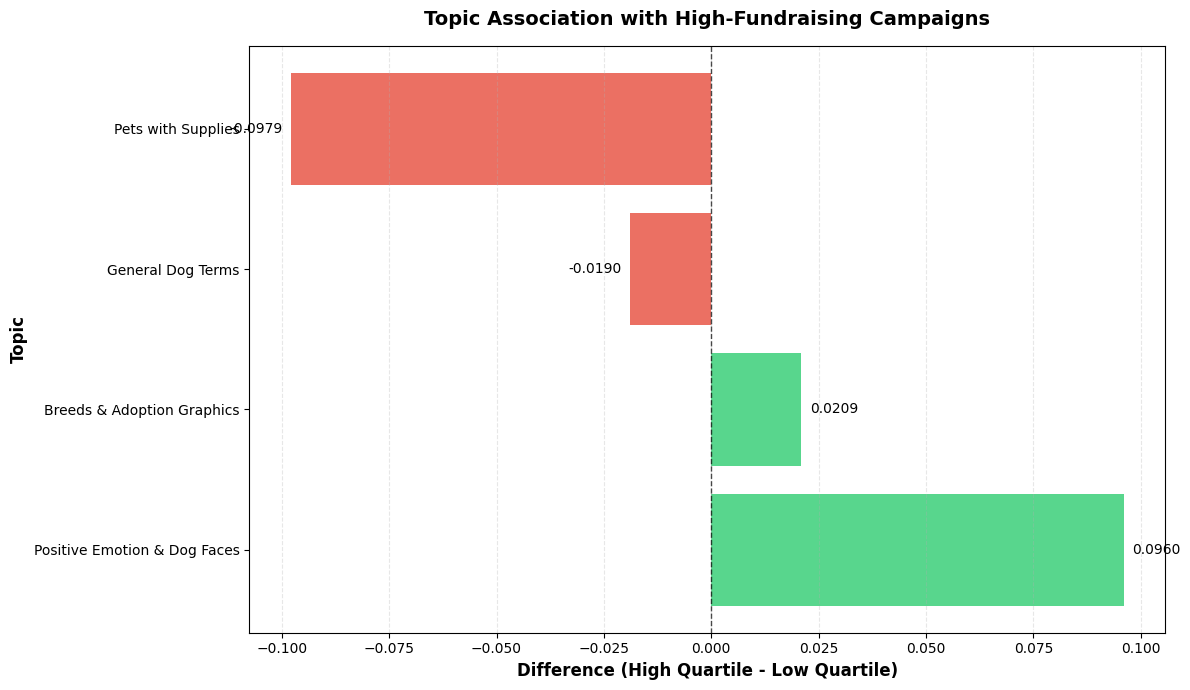

✓ Saved: quartile_comparison_plot.png


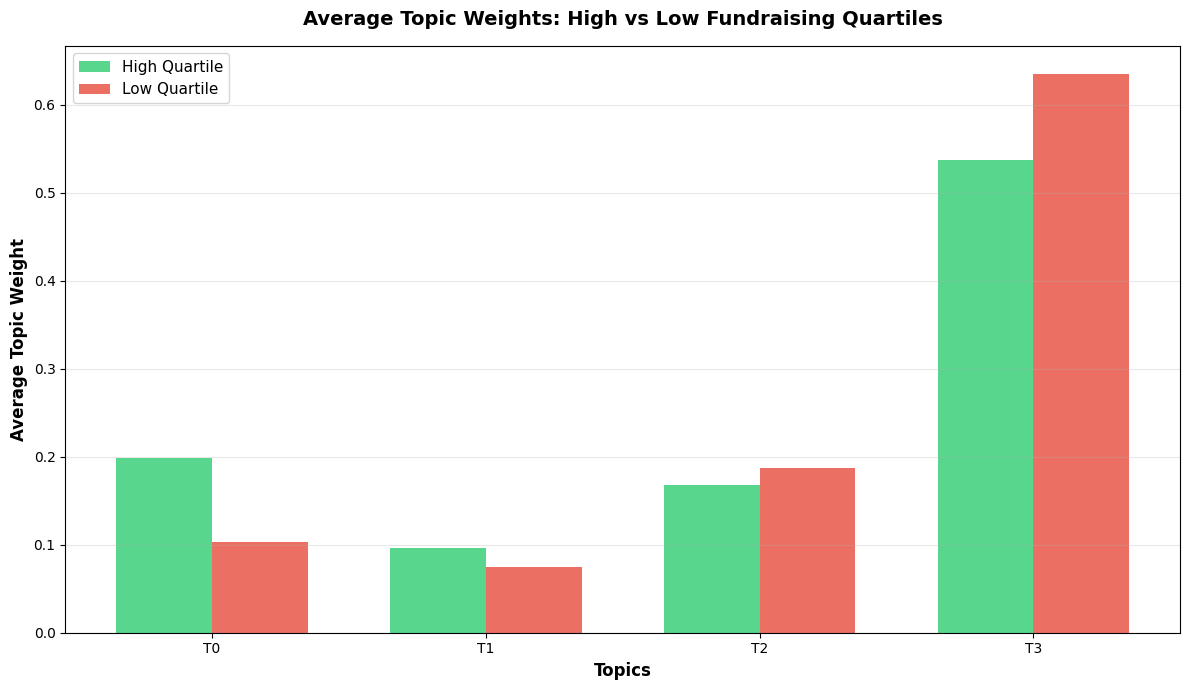


KEY FINDINGS

📈 Most Associated with HIGH Fundraising:
   Positive Emotion & Dog Faces
   Difference: +0.0960

📉 Most Associated with LOW Fundraising:
   Pets with Supplies
   Difference: -0.0979

💡 Interpretation:
   Topics with positive differences are more prevalent in successful campaigns
   Topics with negative differences are more common in less successful campaigns

TASK E COMPLETED!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction import text
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================================
# Load and Prepare Data
# ============================================================================

print("Loading data...")
df_labels = pd.read_csv('labeled_images.csv')
df_scraping = pd.read_csv('gofundme_scrapingdata.csv')

# Clean amount_raised
def clean_amount(amount_str):
    if pd.isna(amount_str):
        return np.nan
    cleaned = re.sub(r'[$,]', '', str(amount_str))
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

df_scraping['amount_raised_numeric'] = df_scraping['amount_raised'].apply(clean_amount)
df_scraping = df_scraping.dropna(subset=['amount_raised_numeric'])

# Merge datasets
df_labels_subset = df_labels[['campaign_number', 'image_labels']]
df_scraping_subset = df_scraping[['campaign_number', 'amount_raised_numeric']]
df_merged = pd.merge(df_labels_subset, df_scraping_subset, on='campaign_number', how='inner')

# Preprocess image labels
def preprocess_labels(label_str):
    if pd.isna(label_str):
        return ""
    text = re.sub(r"[\['\],]", '', str(label_str))
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_merged['labels_clean'] = df_merged['image_labels'].apply(preprocess_labels)
df_merged = df_merged[df_merged['labels_clean'] != '']

print(f"✓ Data prepared: {len(df_merged)} campaigns")

# ============================================================================
# Topic Modeling (LDA)
# ============================================================================

print("\nPerforming LDA Topic Modeling with 4 topics...")

# Define custom stop words
custom_junk_words = [
    'content', 'error', 'url', 'download', 'pass', 'currently',
    'access', 'size', 'exceeds', '10485760', 'allowed'
]
stop_words_list = list(text.ENGLISH_STOP_WORDS.union(custom_junk_words))

# Create Document-Term Matrix
vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=2,
    stop_words=stop_words_list
)
dtm = vectorizer.fit_transform(df_merged['labels_clean'])
feature_names = vectorizer.get_feature_names_out()

# Fit LDA Model with 4 topics
num_topics = 4
lda = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42,
    n_jobs=-1
)
lda.fit(dtm)

# Display Topics
print("\n" + "="*70)
print(f"TOP WORDS FOR {num_topics} TOPICS")
print("="*70)

topic_top_words = []
for topic_idx, topic_distribution in enumerate(lda.components_):
    top_words_idx = topic_distribution.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_words_idx]
    topic_probabilities = topic_distribution / topic_distribution.sum()
    top_word_probabilities = topic_probabilities[top_words_idx]

    print(f"\nTopic {topic_idx}:")
    for word, prob in zip(top_words[:10], top_word_probabilities[:10]):
        print(f"  {word:<20} {prob:.4f}")

    topic_top_words.append(", ".join(top_words))

# Get topic weights for each campaign
topic_weights = lda.transform(dtm)
for i in range(num_topics):
    df_merged[f'Topic_{i}'] = topic_weights[:, i]

print("\n✓ Topic modeling completed")

# ============================================================================
# Assign Topic Names (UPDATE THESE BASED ON YOUR TOPICS)
# ============================================================================

topic_name_map = {
    'Topic 0': 'General Dog Terms',  # Update after reviewing top words
    'Topic 1': 'Positive Emotion & Dog Faces',  # Update after reviewing top words
    'Topic 2': 'Pets with Supplies',  # Update after reviewing top words
    'Topic 3': 'Breeds & Adoption Graphics'   # Update after reviewing top words
}

print("\n⚠️  Review the topics above and update topic_name_map with meaningful names")

# ============================================================================
# Quartile Analysis
# ============================================================================

print("\n" + "="*70)
print("QUARTILE ANALYSIS")
print("="*70)

# Calculate quartiles
q1 = df_merged['amount_raised_numeric'].quantile(0.25)
q3 = df_merged['amount_raised_numeric'].quantile(0.75)

df_high_quartile = df_merged[df_merged['amount_raised_numeric'] >= q3]
df_low_quartile = df_merged[df_merged['amount_raised_numeric'] <= q1]

print(f"\nLow Quartile:  ≤ ${q1:.2f} ({len(df_low_quartile)} campaigns)")
print(f"High Quartile: ≥ ${q3:.2f} ({len(df_high_quartile)} campaigns)")

# Calculate average topic weights
topic_columns = [f'Topic_{i}' for i in range(num_topics)]
high_quartile_avg = df_high_quartile[topic_columns].mean()
low_quartile_avg = df_low_quartile[topic_columns].mean()

# Create results table
results_df = pd.DataFrame({
    'Topic_Num': [f'Topic {i}' for i in range(num_topics)],
    'High_Quartile_Avg': high_quartile_avg.values,
    'Low_Quartile_Avg': low_quartile_avg.values,
    'Difference': high_quartile_avg.values - low_quartile_avg.values
})

results_df['Topic_Name'] = results_df['Topic_Num'].map(topic_name_map)
results_df = results_df.sort_values('Difference', ascending=False)
results_df = results_df[['Topic_Name', 'Topic_Num', 'High_Quartile_Avg',
                         'Low_Quartile_Avg', 'Difference']]

# ============================================================================
# Results Table
# ============================================================================

print("\n" + "="*70)
print("TOPIC WEIGHTS COMPARISON: HIGH vs LOW QUARTILE")
print("="*70)
print(results_df.to_string(index=False, float_format='%.4f'))

# Export results
results_df.to_csv('task_e_topic_analysis.csv', index=False)
print("\n✓ Results saved to: task_e_topic_analysis.csv")

# ============================================================================
# Visualizations
# ============================================================================

print("\nGenerating visualizations...")

# Visualization 1: Topic Difference Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in results_df['Difference']]

ax.barh(results_df['Topic_Name'], results_df['Difference'], color=colors, alpha=0.8)
ax.set_xlabel('Difference (High Quartile - Low Quartile)', fontsize=12, fontweight='bold')
ax.set_ylabel('Topic', fontsize=12, fontweight='bold')
ax.set_title('Topic Association with High-Fundraising Campaigns',
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# Add value labels
for idx, (topic, diff) in enumerate(zip(results_df['Topic_Name'], results_df['Difference'])):
    x_pos = diff + (0.002 if diff > 0 else -0.002)
    ha = 'left' if diff > 0 else 'right'
    ax.text(x_pos, idx, f'{diff:.4f}', va='center', ha=ha, fontsize=10)

plt.tight_layout()
plt.savefig("topic_difference_plot.png", dpi=150, bbox_inches='tight')
print("✓ Saved: topic_difference_plot.png")
plt.show()

# Visualization 2: Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['High_Quartile_Avg'],
               width, label='High Quartile', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df['Low_Quartile_Avg'],
               width, label='Low Quartile', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Topics', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Topic Weight', fontsize=12, fontweight='bold')
ax.set_title('Average Topic Weights: High vs Low Fundraising Quartiles',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f"T{i}" for i in range(num_topics)])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("quartile_comparison_plot.png", dpi=150, bbox_inches='tight')
print("✓ Saved: quartile_comparison_plot.png")
plt.show()


# ============================================================================
# Key Findings
# ============================================================================

print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

# Identify topics with largest positive and negative differences
most_positive = results_df.iloc[0]
most_negative = results_df.iloc[-1]

print(f"\n📈 Most Associated with HIGH Fundraising:")
print(f"   {most_positive['Topic_Name']}")
print(f"   Difference: +{most_positive['Difference']:.4f}")

print(f"\n📉 Most Associated with LOW Fundraising:")
print(f"   {most_negative['Topic_Name']}")
print(f"   Difference: {most_negative['Difference']:.4f}")

print("\n💡 Interpretation:")
print("   Topics with positive differences are more prevalent in successful campaigns")
print("   Topics with negative differences are more common in less successful campaigns")

print("\n" + "="*70)
print("TASK E COMPLETED!")
print("="*70)

# Task F

What advice would you give to the organization if it wants to increase the $ raised based on your findings?   

Based on our findings, we think there are several factors would help an organization looking to improve their dog rescue pages on sites similar to GoFundMe. First, visual content is more predictive of fundraising success than descriptors. This is with taking duration of the post into account. Posts with strong visual content outperformed in fundraising and made clear that people find visual content to be more emotionally appealing than descriptive content.

We then also uncovered four key topics that posts fall into: General Dog Terms, Positive Emotion & Dog Faces, Pets with Supplies, and Breeds & Adoption Graphics. Our analysis showed that the topic Positive Emotion & Dog Faces was most associated with high fundraising efforts (where campaigns made more than about $3,500). The kind of image labels associated with this topic label included things like happiness, smile, facial, expression, and selfie. This, along with the visual content indicator, highlights that posts of dogs that were seen as more expressive (especially positively expressive) are more likely to be associated with higher fundraising. This proves that images capturing positive emotions and close-ups of dog faces are more prevalent in successful campaigns.

Conversely, the topic Pets with Supplies had the largest negative difference, suggesting that images primarily featuring pet supplies might be less effective in driving donations compared to images focusing on the animal's face and emotional state.

Overall, we would suggest that an organization focus on posting images of dogs that capture the dog's face and convey positive emotions (happiness, relief, playfulness) and put a greater emphasis on their images rather than on their description of the dog/the fundraising effort. Images showing the dog looking directly at the camera with a seemingly happy or hopeful expression may be particularly effective. While necessary, the organizations should avoid showing images of crates, food bowls, or medical supplies the primary visual element of a campaign. These might be less compelling to potential donors compared to images of the animal itself.